`TCS Stock Price Analysis – Data Cleaning, Preprocessing & Exploratory Data Analysis`

#### Description:
* In this part of the project, I focused on understanding and preparing Tata Consultancy Services (TCS) stock market data for analysis. The objective was to clean raw financial data, preprocess it for consistency, select meaningful features, and perform exploratory data analysis (EDA) to identify patterns and trends in stock prices.

* The dataset contains historical stock price information such as `Date, Open, High, Low, Close prices, Volume, dividends and stock_splits`. Since raw market data often contains missing values, inconsistencies, and noise, proper preprocessing was required before applying any predictive models.

## 1. Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

## 2. Load Dataset

In [2]:
# Creating database connection
conn = psycopg2.connect(
    host = "localhost",
    database = "internprojects",
    password = "xyz",
    user = "postgres",
    port = "5432"
)

In [3]:
# Checking tables present in the database
tables = pd.read_sql_query("SELECT table_name FROM information_schema.tables WHERE table_schema = 'public' ", conn)
tables

,table_name
0,netflix1
1,supermart_grocery_sales
2,tcs_stock_action
3,tcs_stock_history
4,tcs_stock_info


In [4]:
# fetch tcs_stock_history.
df = pd.read_sql('SELECT * FROM "tcs_stock_history"; ', conn)
df.head()

,date,open,high,low,close,volume,dividends,stock_splits
0,2002-08-12,28.794172,29.742206,28.794172,29.519140,212976,0.0,0.0
1,2002-08-13,29.556316,30.030333,28.905705,29.119476,153576,0.0,0.0
2,2002-08-14,29.184536,29.184536,26.563503,27.111877,822776,0.0,0.0
3,2002-08-15,27.111877,27.111877,27.111877,27.111877,0,0.0,0.0
4,2002-08-16,26.972458,28.255089,26.582090,27.046812,811856,0.0,0.0


## 3. Data Cleaning & Preprocessing

In [5]:
# Copy Dataset
data = df.copy()

In [6]:
# Check Columns, data types and Missing Values.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4463 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          4463 non-null   object 
 1   open          4463 non-null   float64
 2   high          4463 non-null   float64
 3   low           4463 non-null   float64
 4   close         4463 non-null   float64
 5   volume        4463 non-null   int64  
 6   dividends     4463 non-null   float64
 7   stock_splits  4463 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 279.1+ KB


In [7]:
# Check for missing values in each columns.
data.isnull().sum()

date            0
open            0
high            0
low             0
close           0
volume          0
dividends       0
stock_splits    0
dtype: int64

In [8]:
data.shape

(4463, 8)

In [9]:
# Check duplicate values
data.duplicated().sum()

np.int64(0)

In [10]:
# Check how many 0 values in 'volume' column
(data['volume'] == 0).sum()

np.int64(25)

In [11]:
# Remove NaN vlaues.. 
data['volume'] = data['volume'].replace(0, np.nan)
data = data.dropna(subset=['volume'])

data['volume'] = data['volume'].astype(int)

In [12]:
data.shape

(4438, 8)

* I identified zero-volume anomalies in the dataset and removed them, as they represented less than 1% of the data and could negatively impact EDA and predictive modeling.

In [13]:
# Convert 'date' to datetime.
data['date'] = pd.to_datetime(data['date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4438 entries, 0 to 4462
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          4438 non-null   datetime64[ns]
 1   open          4438 non-null   float64       
 2   high          4438 non-null   float64       
 3   low           4438 non-null   float64       
 4   close         4438 non-null   float64       
 5   volume        4438 non-null   int64         
 6   dividends     4438 non-null   float64       
 7   stock_splits  4438 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 312.0 KB


## 4. Exploratory Data Analysis (EDA)

In [14]:
# Statistical summary
data.describe()

,date,open,high,low,close,volume,dividends,stock_splits
count,4438,4438.000000,4438.000000,4438.000000,4438.000000,4.438000e+03,4438.000000,4438.000000
mean,2012-09-08 01:32:28.445245696,870.955560,880.749195,860.615250,870.554474,3.557806e+06,0.071936,0.001352
min,2002-08-12 00:00:00,24.146938,27.102587,24.146938,26.377609,4.560000e+03,0.000000,0.000000
25%,2008-03-05 12:00:00,190.415985,192.649294,186.710363,189.661926,1.872004e+06,0.000000,0.000000
50%,2012-09-19 00:00:00,534.767560,538.051891,527.963812,534.704865,2.768333e+06,0.000000,0.000000
75%,2017-03-30 18:00:00,1156.640133,1167.213533,1144.921433,1155.222900,4.284931e+06,0.000000,0.000000
max,2021-09-30 00:00:00,3930.000000,3981.750000,3892.100098,3954.550049,8.806715e+07,40.000000,2.000000
std,NaN,830.246101,838.604028,821.578941,829.952452,3.271920e+06,0.968102,0.051988


`Summary Statistics Insights:`
* The dataset contains 4,438 records of TCS stock data from 2002 to 2021.
* Stock prices (open, high, low, close) show a strong long-term upward trend with high variability, indicating market volatility.
* Trading volume varies significantly, reflecting changing investor activity over time.
* Dividend and stock split values are mostly zero, showing that these corporate actions occur only on specific dates.

* Overall, the dataset is well-structured, informative, and suitable for trend analysis and predictive modeling.

In [15]:
# Correlation of features with the target variable (Close Price)
correlation_with_close = data.corr()['close'].sort_values(ascending=False)
print(correlation_with_close)

close           1.000000
high            0.999914
low             0.999901
open            0.999786
date            0.899550
dividends       0.059965
stock_splits   -0.006777
volume         -0.158981
Name: close, dtype: float64


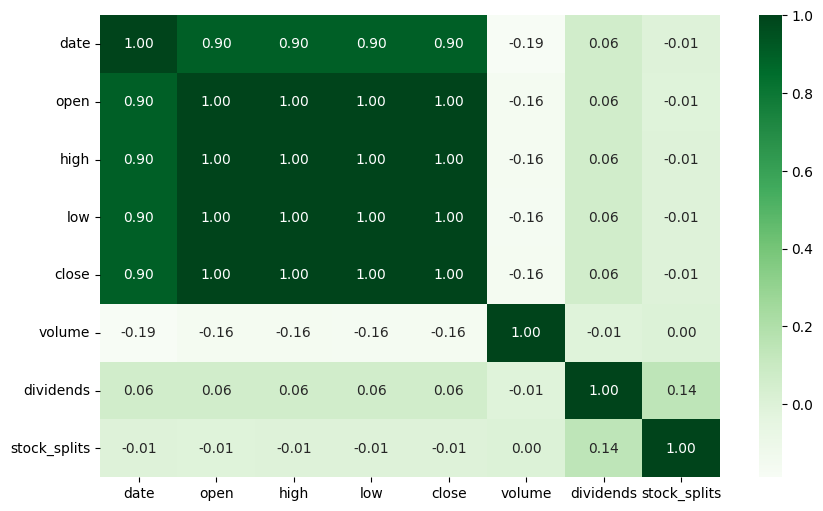

In [16]:
# Correlation Of Features
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap="Greens", fmt=".2f")
plt.show()

`Correlation Insights`
* Open, High, Low, and Close prices show a strong positive correlation, indicating they move together.

* There is high multicollinearity among price-related features, so using all of them may be redundant for modeling.

* Volume has a weak negative correlation with price, suggesting limited direct influence on price movement.

* Dividends and stock splits have negligible correlation with stock prices as they are corporate actions.

* Date shows a strong correlation with price, reflecting the long-term trend in the stock.

## 5. TCS stock Analysis

* Price Trends: Visualize the Open, Close, High, and Low prices over time.
* Volume Analysis: Analyze trading volumes.
* Moving Averages: Calculate moving averages for trend analysis.

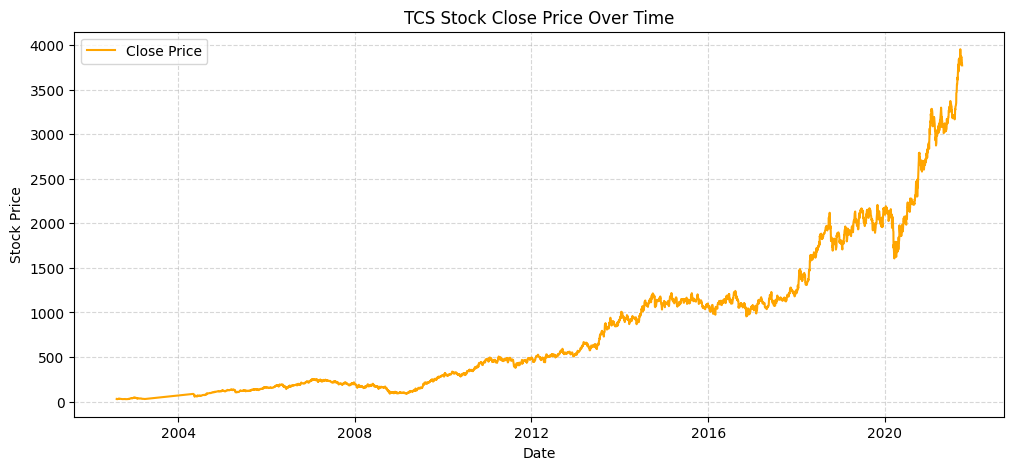

In [17]:
# Plotting Close price over time
plt.figure(figsize=(12, 5))
plt.plot(data['date'], data['close'], color='orange', label='Close Price')

plt.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('TCS Stock Close Price Over Time')
plt.legend()
plt.show()

In [18]:
# Calculating 50-day and 200-day moving averages
data['MA50'] = data['close'].rolling(window=50).mean()
data['MA200'] = data['close'].rolling(window=200).mean()

`Moving Average Insights (TCS Stock)`

* The stock shows a strong long-term upward trend, as the closing price consistently rises over time.

* The 50-day moving average closely follows the price, capturing short-term trend changes.

* The 200-day moving average remains smooth, indicating stable long-term growth.

* Periods where the 50-day MA stays above the 200-day MA reflect bullish market conditions.

* Short-term price corrections do not break the long-term trend, showing overall market strength.

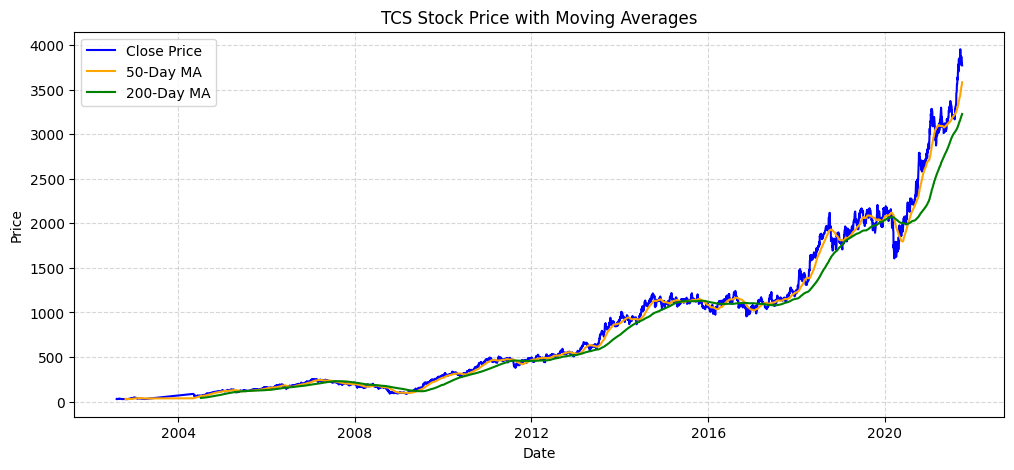

In [19]:
# Plot with Moving Averages
plt.figure(figsize=(12, 5))
plt.plot(data['date'], data['close'], color='blue', label='Close Price') # Close price
plt.plot(data['date'], data['MA50'], color='orange', label='50-Day MA') # 50-day Moving Average
plt.plot(data['date'], data['MA200'], color='green', label='200-Day MA') # 200-day Moving Average

plt.grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('TCS Stock Price with Moving Averages')
plt.legend()
plt.show()

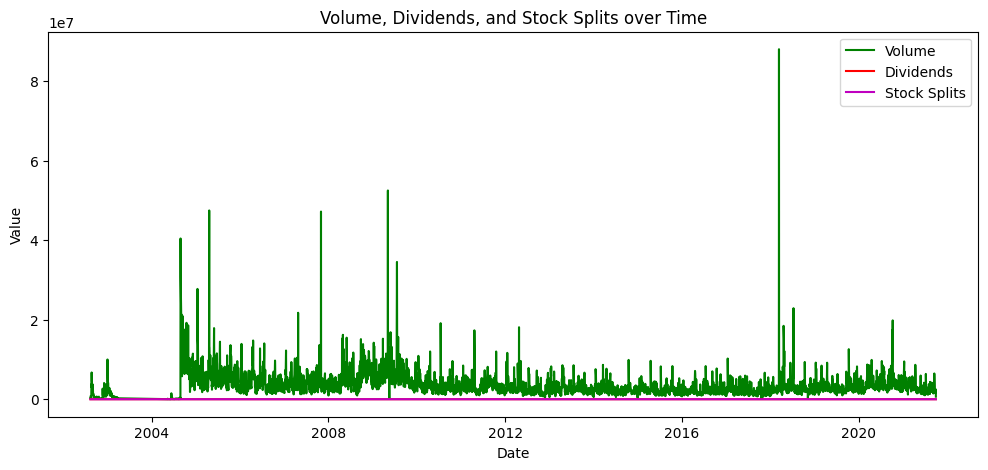

In [20]:
# Volume, Dividends, Stock Splits
plt.figure(figsize=(12, 5))

plt.plot(data['date'], data['volume'], label='Volume', color='g')
plt.plot(data['date'], data['dividends'], label='Dividends',color='r')
plt.plot(data['date'], data['stock_splits'], label='Stock Splits', color='m')

plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Volume, Dividends, and Stock Splits over Time')
plt.legend()
plt.show()

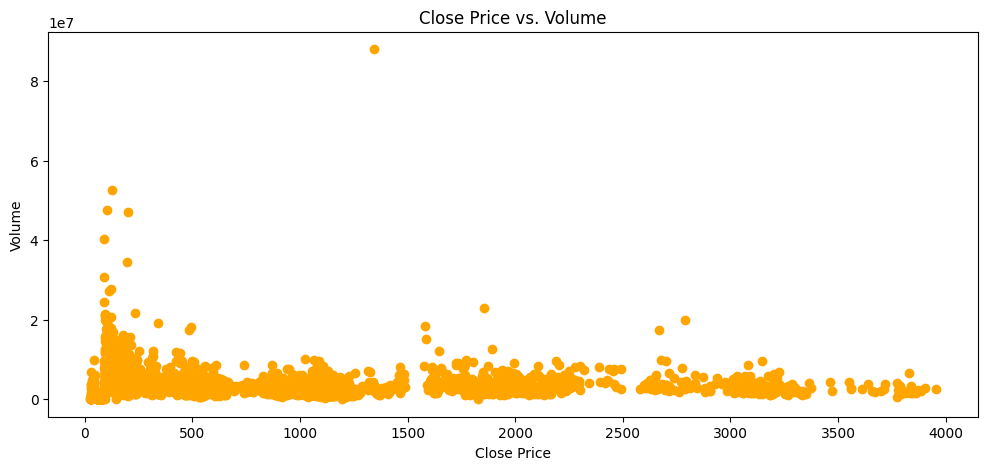

In [21]:
# Close vs Volume
plt.figure(figsize=(12, 5))

plt.scatter(data['close'], data['volume'], color='orange')

plt.xlabel('Close Price')
plt.ylabel('Volume')
plt.title('Close Price vs. Volume')
plt.show()

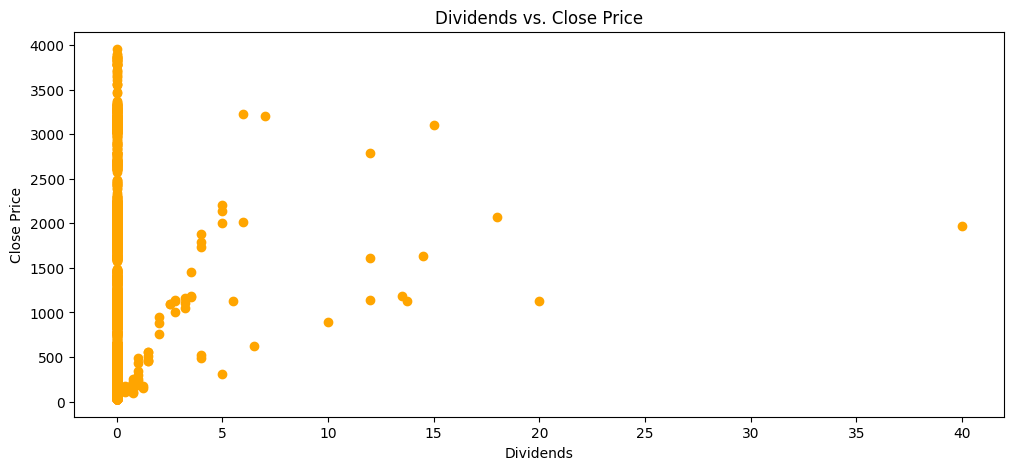

In [22]:
# Dividends vs. Close Price
plt.figure(figsize=(12, 5))

plt.scatter(data['dividends'], data['close'], color='orange')
plt.xlabel('Dividends')
plt.ylabel('Close Price')
plt.title('Dividends vs. Close Price')
plt.show()

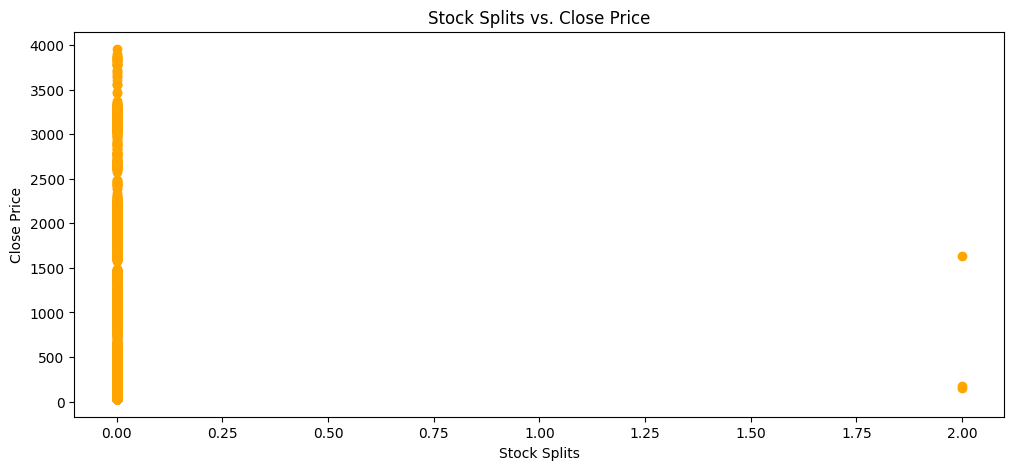

In [23]:
# Stock Splits vs. Close Price
plt.figure(figsize=(12, 5))

plt.scatter(data['stock_splits'], data['close'], color='orange')
plt.xlabel('Stock Splits')
plt.ylabel('Close Price')
plt.title('Stock Splits vs. Close Price')
plt.show()

`Insights`
* Trading volume is highly volatile with sharp spikes on certain dates.

* Dividends are mostly zero, indicating that dividend events are rare.

* Stock splits occur very infrequently and only on specific dates.

* Volume fluctuates over time but does not consistently follow the price trend.

* Dividends and stock splits show limited direct impact on daily trading activity.

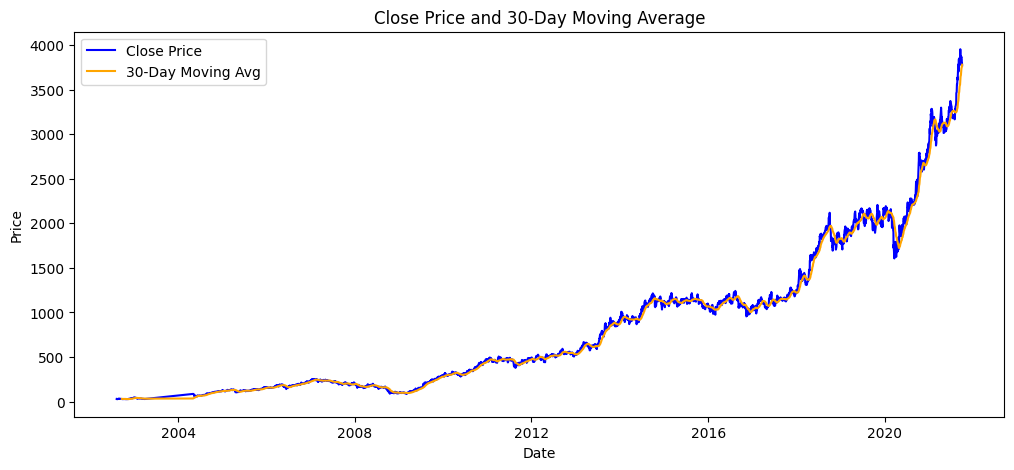

In [24]:
# Moving Averages
data['30-Day Moving Avg'] = data['close'].rolling(window=30).mean()

# Plot Close price and moving average
plt.figure(figsize=(12, 5))
plt.plot(data['date'], data['close'], label='Close Price',color='blue')
plt.plot(data['date'], data['30-Day Moving Avg'], label='30-Day Moving Avg', color='orange')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Close Price and 30-Day Moving Average')
plt.legend()
plt.show()

In [25]:
# Moving Average Crossover Strategy
data['Short_MA'] = data['close'].rolling(window=5).mean()
data['Long_MA'] = data['close'].rolling(window=30).mean()

# Creating a trading signals based on moving average crossovers
data['Signal'] = np.where(data['Short_MA'] > data['Long_MA'], 1,-1)

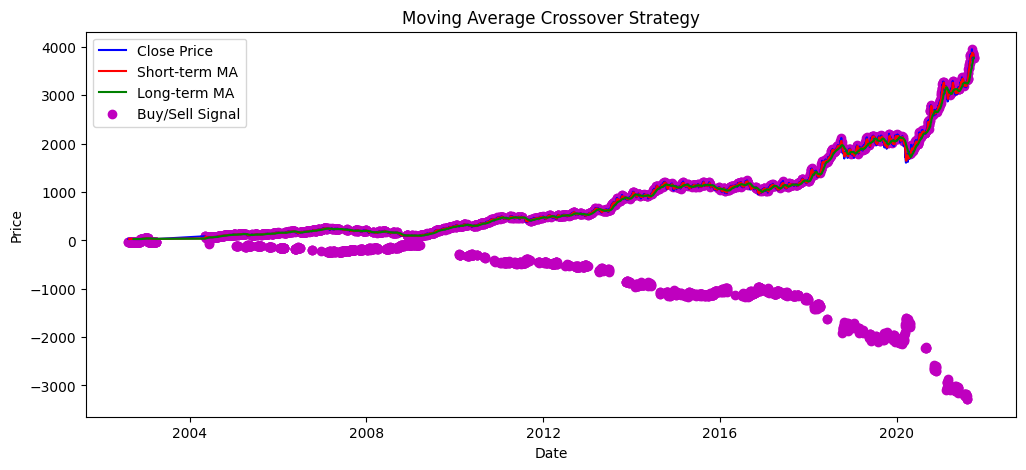

In [26]:
# Plot the strategy signals
plt.figure(figsize=(12, 5))
plt.plot(data['date'], data['close'], label='Close Price',color='b')
plt.plot(data['date'], data['Short_MA'], label='Short-term MA',color='r')
plt.plot(data['date'], data['Long_MA'], label='Long-term MA',color='g')

plt.scatter(data['date'], data['close'] * data['Signal'], label='Buy/Sell Signal', marker='o', color='m')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Moving Average Crossover Strategy')
plt.legend()
plt.show()

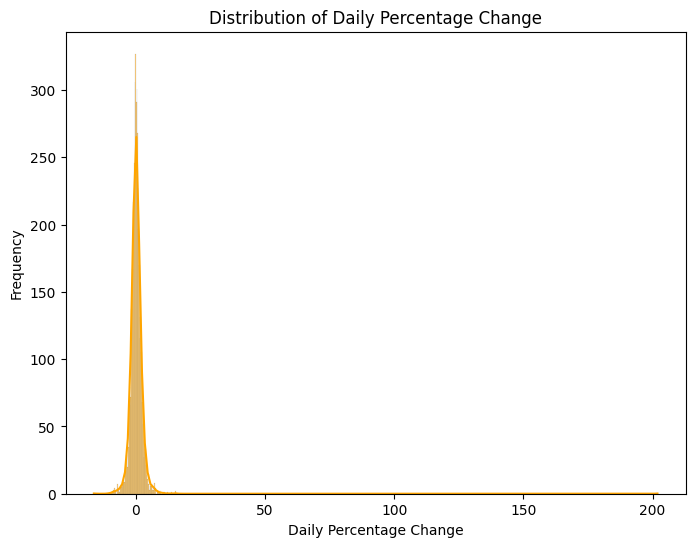

In [27]:
# Daily Price Change
data['Daily_Price_Change'] = data['close'].pct_change() * 100

# Distribution of daily percentage change
plt.figure(figsize=(8, 6))
sns.histplot(data['Daily_Price_Change'].dropna(), kde=True, color='orange')
plt.xlabel('Daily Percentage Change')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Percentage Change')
plt.show()

## 6. Feature Engineering
* Extract features like Year, Month, Day, Day of Week from Date.
* Create lag features (e.g., previous day’s close, previous day’s high/low).

In [28]:
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day
data['day_of_week'] = data['date'].dt.dayofweek

In [29]:
# Lag Features
data['Prev_Close'] = data['close'].shift(1)
data.dropna(inplace=True) # Drop rows with NaN values from shifting

In [30]:
data.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'dividends',
       'stock_splits', 'MA50', 'MA200', '30-Day Moving Avg', 'Short_MA',
       'Long_MA', 'Signal', 'Daily_Price_Change', 'year', 'month', 'day',
       'day_of_week', 'Prev_Close'],
      dtype='object')

In [32]:
features = ['open', 'high', 'low', 'close', 'volume', 'Prev_Close', 'day_of_week', 'month']

In [33]:
# Save the cleaned dataset for Tableau

data = data[features]

data.to_csv('TCS_cleaned_data.csv', index=False)

print("Dataset saved successfully")

Dataset saved successfully


# `7. Explanation Summary`
* This project covers EDA, visualization, and feature engineering, for TCS stock prices:
    1. EDA provides insights into the stock's historical patterns.
    2. Moving Averages help smooth out price trends.